# Motion trimming demo - dead frames in lerobot/droid_1.0.1

Robot episodes open with the operator setting up and end after the task is done - dead frames that cost decode time, VLM tokens, and training steps. This demo finds them **without decoding video**: the robot's own joint positions live in parquet next to the mp4, and a still arm is a columnar scan away.

Two outputs, for two kinds of consumer: a per-frame `is_active` flag (for training that samples frames - drops interior pauses too) and one contiguous trim window per episode (for anything that decodes a video slice).

## Setup

Install with `pip install daft-physical-ai matplotlib`, then import.

In [1]:
import daft
from daft import col
from daft.datasets import lerobot

from daft_physical_ai.proprio import is_active, motion_energy, motion_scale
from daft_physical_ai.trim import trim_windows

## Configure

The dataset, its state column, and how many of its data files to read. Everything streams from Hugging Face - the video is never touched.

In [2]:
DATASET = "lerobot/droid_1.0.1"
STATE = "observation.state.joint_position"  # the robot's own joint positions, one list per frame
DIMS = 7
FPS = 15
SHARDS = 1  # data files to read (DROID has 156; one is ~1,000 episodes)

## Build the frame DataFrame

One row per frame: episode metadata from Daft's LeRobot reader joined to the per-frame parquet.

In [3]:
root = f"hf://datasets/{DATASET}"
episodes = lerobot.read_episodes(root).select(
    "episode_index",
    col("tasks").list_join("; ").alias("task"),
    "dataset_from_index",
)
shards = [f"{root}/data/chunk-000/file-{i:03d}.parquet" for i in range(SHARDS)]
frames = episodes.join(daft.read_parquet(shards), on="episode_index")

# droid_1.0.1 quirk: some episodes carry an orphan second recording under the
# same episode_index. A canonical row sits exactly at dataset_from_index +
# frame_index; orphans never do, so one filter drops them.
frames = frames.where(col("index") == col("dataset_from_index") + col("frame_index"))
frames = frames.select("episode_index", "task", "frame_index", STATE)
frames.show(5)

episode_indexInt64,taskString,frame_indexInt64,observation.state.joint_positionList[Float32]
0,,0,"[-0.22476004, -0.42106023, -0.12811285, -2.3547568, -0.19623408, 2.2180023, 0.026388178]"
0,,1,"[-0.2259924, -0.42104504, -0.12894471, -2.354736, -0.19623478, 2.2179976, 0.026409931]"
0,,2,"[-0.2264528, -0.42108214, -0.13033146, -2.3547308, -0.19622967, 2.2180026, 0.026413884]"
0,,3,"[-0.22645342, -0.4210798, -0.13150918, -2.3547342, -0.19623081, 2.2180016, 0.026413696]"
0,,4,"[-0.22645289, -0.4210563, -0.13189712, -2.354731, -0.19623081, 2.218003, 0.026413696]"


## Score the motion

`motion_energy` measures how much the arm moved since the previous frame - each joint's change, normalized by that joint's typical step, combined into one number. `is_active` thresholds it, requiring 3 consecutive frames of motion so a single noisy frame doesn't count. Idle frames sit near zero; real motion is orders of magnitude above.

In [4]:
scale = motion_scale(frames, STATE, dims=DIMS)  # one pass: the typical per-dim step
frames = (
    frames
    .with_column("motion_energy", motion_energy(col(STATE), dims=DIMS, scale=scale))
    .with_column("is_active", is_active(col("motion_energy")))
)

## Reduce to trim windows

One row per episode: the span from the first sustained motion to the last, padded 0.25s on each side. Episodes where the arm never moves at all - aborted takes - keep their full span and get flagged `never_active` instead of being trimmed to nothing.

In [5]:
windows = trim_windows(frames, fps=FPS)
windows.sort("trim_fraction", desc=True).show(5)

episode_indexInt64,start_frameInt64,end_frameInt64,start_tsFloat64,end_tsFloat64,kept_framesInt64,trim_fractionFloat64,never_activeBool
50,402,533,26.8,35.53333333333333,132,0.7573529411764706,false
748,62,89,4.133333333333334,5.933333333333334,28,0.711340206185567,false
1050,58,105,3.8666666666666667,7,48,0.6962025316455696,false
234,241,380,16.066666666666666,25.333333333333332,140,0.6464646464646464,false
710,328,567,21.866666666666667,37.8,240,0.590443686006826,false


## See the spread

Motion-energy curves with the kept window shaded: the most-trimmed episode, the median, and the least. The flat stretches outside a window are the operator not yet doing anything; an already-clean episode keeps nearly everything.

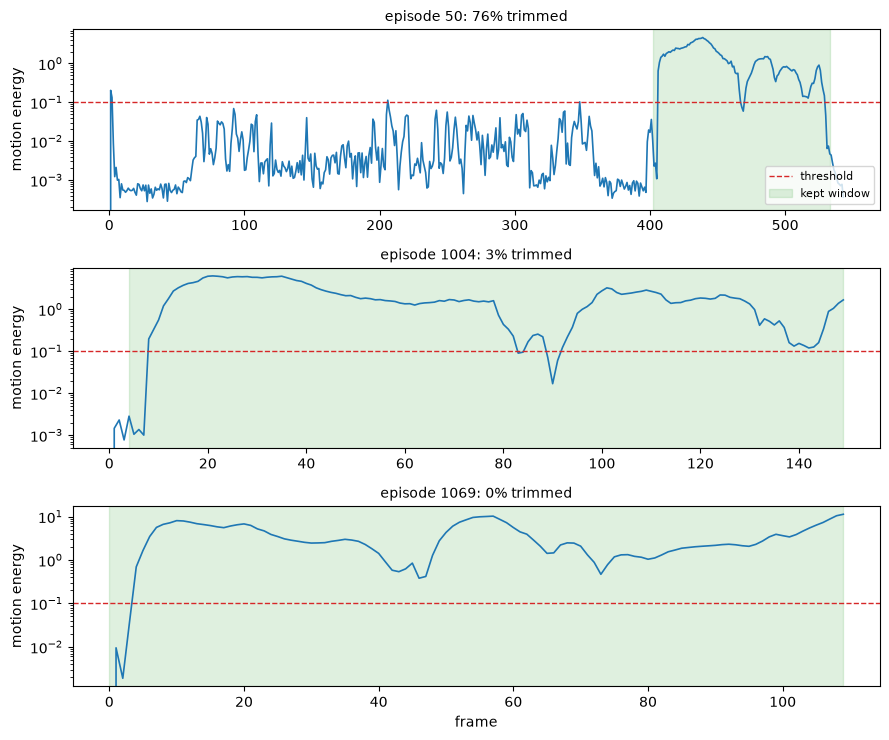

In [6]:
import matplotlib.pyplot as plt

ranked = windows.where(~col("never_active")).sort("trim_fraction", desc=True).to_pylist()
picks = [ranked[0], ranked[len(ranked) // 2], ranked[-1]]  # most trimmed, median, least

fig, axes = plt.subplots(len(picks), 1, figsize=(9, 7.5))
for ax, w in zip(axes, picks):
    ep = w["episode_index"]
    curve = (
        frames.where(col("episode_index") == ep)
        .sort("frame_index")
        .select("frame_index", "motion_energy")
        .to_pydict()
    )
    ax.plot(curve["frame_index"], curve["motion_energy"], lw=1.2)
    ax.axhline(0.1, ls="--", lw=1, color="tab:red", label="threshold")
    ax.axvspan(w["start_frame"], w["end_frame"], color="tab:green", alpha=0.15, label="kept window")
    ax.set_yscale("log")
    ax.set_ylabel("motion energy")
    ax.set_title(f"episode {ep}: {w['trim_fraction']:.0%} trimmed", fontsize=10)
axes[0].legend(loc="lower right", fontsize=8)
axes[-1].set_xlabel("frame")
plt.tight_layout()
plt.show()

## What it saves

Both views over everything scanned. To trim the video itself, pass `from_ts=` (the episode's `videos/{key}/from_timestamp`) to `trim_windows` and the window comes back as absolute timestamps a decoder - or `daft_physical_ai.rewards.score_rewards` - can seek to.

In [7]:
totals = frames.agg(
    col("is_active").cast(daft.DataType.int64()).sum().alias("active"),
    col("frame_index").count().alias("total"),
).to_pydict()
kept = windows.agg(col("kept_frames").sum().alias("kept")).to_pydict()["kept"][0]

total, active = totals["total"][0], totals["active"][0]
print(f"{total} frames scanned")
print(f"window view:    keeps {kept}  (drops {1 - kept / total:.1%})")
print(f"per-frame view: keeps {active}  (drops {1 - active / total:.1%})")

321344 frames scanned
window view:    keeps 308363  (drops 4.0%)
per-frame view: keeps 285419  (drops 11.2%)
